In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from transformers import EncodecModel
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy import signal as sp
import torch.nn.functional as F

import utils_norcia as u

In [10]:
print(torch.cuda.is_available())
if torch.cuda.is_available():  
    dev = "cuda" 
    map_location=None
else:  
    dev = "cpu"  
    map_location='cpu'
device = torch.device(dev)

True


In [11]:
# embedding_inp = True trains the model with the input embedded with our frozen Encoder + classification head
# embedding_inp = False trains the model with the CNN model from Laurenti et al. (2024)
embedding_inp=True
# few_shot = True trains the model with 2% of the data
# few_shot = False trains the model with 70% of the data
few_shot=False
num_classes=2 # chose between 2, 4, 8, 9
if few_shot:
    trValTest_split_rnd=True
else:
    trValTest_split_rnd=False

seed=1234
u.seed_everything(seed)

Setting seeds


In [12]:
df_empty = pd.DataFrame(columns = ['E_channel', 'N_channel', 'Z_channel', 'trace_name', 'label',
       'trace_start_time', 'network_code', 'receiver_name', 'receiver_type',
       'receiver_elevation_m', 'receiver_latitude', 'receiver_longitude',
       'source_id', 'source_depth_km', 'source_latitude', 'source_longitude',
       'source_magnitude_type', 'source_magnitude', 'source_origin_time', 'p_travel_sec'])
df_pre = df_empty.copy() 
df_visso = df_empty.copy() # if num_classes!=9 this df will remain empty
df_post = df_empty.copy()

df_pre = pd.read_pickle('dataframe_pre_NRCA.csv')
df_post = pd.read_pickle('dataframe_post_NRCA.csv')
if num_classes==9:
    df_visso = pd.read_pickle('dataframe_visso_NRCA.csv')
df_pre, df_visso, df_post=u.pre_post_equal_length(df_pre=df_pre, df_visso=df_visso, df_post=df_post, num_classes=num_classes)

df_pre['trace_start_time'] = df_pre['trace_start_time'].apply(lambda x: datetime.strptime(x, '%Y-%m-%dT%H:%M:%S.%fZ'))
df_visso['trace_start_time'] = df_visso['trace_start_time'].apply(lambda x: datetime.strptime(x, '%Y-%m-%dT%H:%M:%S.%fZ'))
df_post['trace_start_time'] = df_post['trace_start_time'].apply(lambda x: datetime.strptime(x, '%Y-%m-%dT%H:%M:%S.%fZ'))

In [13]:
if num_classes==2:
    df=pd.concat([df_pre, df_post], ignore_index=True)
else:
    frames_pre = u.frames_N_classes(df_pre,num_classes, pre_or_post="pre")
    frames_post = u.frames_N_classes(df_post,num_classes, pre_or_post="post")
    if num_classes==9:
        frames_visso = u.frames_N_classes(df_visso,num_classes, pre_or_post="visso")
        df=pd.concat([pd.concat(frames_pre),pd.concat(frames_visso),pd.concat(frames_post)], ignore_index=True)
    else:
        df=pd.concat([pd.concat(frames_pre),pd.concat(frames_post)], ignore_index=True)

In [14]:
df['source_origin_time'] = df['source_origin_time'].apply(lambda x: datetime.strptime(x, '%Y-%m-%dT%H:%M:%S'))
df['TTF'] = df.apply (lambda row: u.add_TTF_in_sec(row), axis=1)
df

,E_channel,N_channel,Z_channel,trace_name,label,trace_start_time,network_code,receiver_name,receiver_type,receiver_elevation_m,...,receiver_longitude,source_id,source_depth_km,source_latitude,source_longitude,source_magnitude_type,source_magnitude,source_origin_time,p_travel_sec,TTF
0,"[132.1705571967854, 66.95636685258737, -131.25...","[-708.1844911915332, -725.1333214474403, -248....","[-300.8230386502328, -542.8045684640165, -473....",NRCA.IV.100605665_EV,"[1, 0]",2016-08-26 12:58:42.850,IV,NRCA,HH,927,...,13.11427,100605665,7.832,42.82371,13.15882,Mw,0.81,2016-08-26 12:58:46,1.85,-5596891.0
1,"[-29.930644528759444, 35.700982034044614, 119....","[107.12269336869673, 83.2137174850933, 135.304...","[-177.04816298899823, -258.0287031071475, -289...",NRCA.IV.100132734_EV,"[1, 0]",2016-10-09 23:15:37.910,IV,NRCA,HH,927,...,13.11427,100132734,3.133,42.85712,13.12936,Mw,1.64,2016-10-09 23:15:42,0.91,-1758275.0
2,"[-32.301188876967444, -4.31056455921248, -66.3...","[17.672950004650374, 11.630989493507172, 5.589...","[76.46197156629205, 161.46057743886013, 181.45...",NRCA.IV.100789725_EV,"[1, 0]",2016-09-09 21:41:13.420,IV,NRCA,HH,927,...,13.11427,100789725,5.196,42.80822,13.15178,Mw,0.94,2016-09-09 21:41:17,1.42,-4355940.0
3,"[-56.75715613035345, -136.60137791444572, -141...","[-18.92074153551971, -71.94232145568594, -68.9...","[87.12672532905526, 134.11767712752044, 60.108...",NRCA.IV.100657798_EV,"[1, 0]",2016-09-12 00:59:25.300,IV,NRCA,HH,927,...,13.11427,100657798,4.994,42.81180,13.14592,Mw,0.54,2016-09-12 00:59:29,1.30,-4171248.0
4,"[-31.010474467287622, -17.97208751914127, -51....","[24.0180225272004, 69.04365704960242, 49.06929...","[142.18171052921753, 169.16752885531696, 240.1...",NRCA.IV.100710907_EV,"[1, 0]",2016-09-21 07:17:16.300,IV,NRCA,HH,927,...,13.11427,100710907,4.509,42.81145,13.15512,Mw,0.64,2016-09-21 07:17:20,1.30,-3370977.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7251,"[-543.0040453842441, -14.842991048376689, -112...","[-310.3318797181373, -324.192483306726, -335.0...","[-72.18099714550652, -323.19248897314, -178.20...",NRCA.IV.100156350_EV,"[0, 1]",2016-11-11 07:14:16.960,IV,NRCA,HH,927,...,13.11427,100156350,3.937,42.85118,13.10115,Mw,1.08,2016-11-11 07:14:21,0.96,1035244.0
7252,"[-3113.5233024296267, 618.4591864242319, 3232....","[196.12292253362415, -1074.0331598108, -794.18...","[1431.8399211058968, 294.8662796368226, -1200....",NRCA.IV.100133526_EV,"[0, 1]",2016-11-01 01:16:44.750,IV,NRCA,HH,927,...,13.11427,100133526,5.293,42.93290,13.06387,Mw,2.83,2016-11-01 01:16:47,2.75,149790.0
7253,"[11736.187347602925, 11828.54954430621, 11753....","[11875.9545275415, 11830.188712500036, 11812.4...","[11660.545018443474, 11611.50416979377, 11598....",NRCA.IV.100448117_EV,"[0, 1]",2016-12-17 12:45:53.450,IV,NRCA,HH,927,...,13.11427,100448117,5.159,42.87098,13.13276,Mw,1.51,2016-12-17 12:45:57,1.45,4165540.0
7254,"[5431.8656738743375, 1413.9051326347185, 2089....","[-146.90272380256414, -6756.363641927401, -785...","[-4661.762612940423, -1767.680683057988, -2616...",NRCA.IV.100107186_EV,"[0, 1]",2016-10-31 14:39:35.370,IV,NRCA,HH,927,...,13.11427,100107186,5.065,42.81246,13.15410,Mw,2.38,2016-10-31 14:39:39,1.37,111562.0


first event in pre is on  2016-08-20 12:07:51.300000  last event in pre is on  2016-10-26 14:49:08.390000
first event in post is on  2016-10-31 00:02:23.470000  last event in post is on  2016-12-20 07:10:40.380000


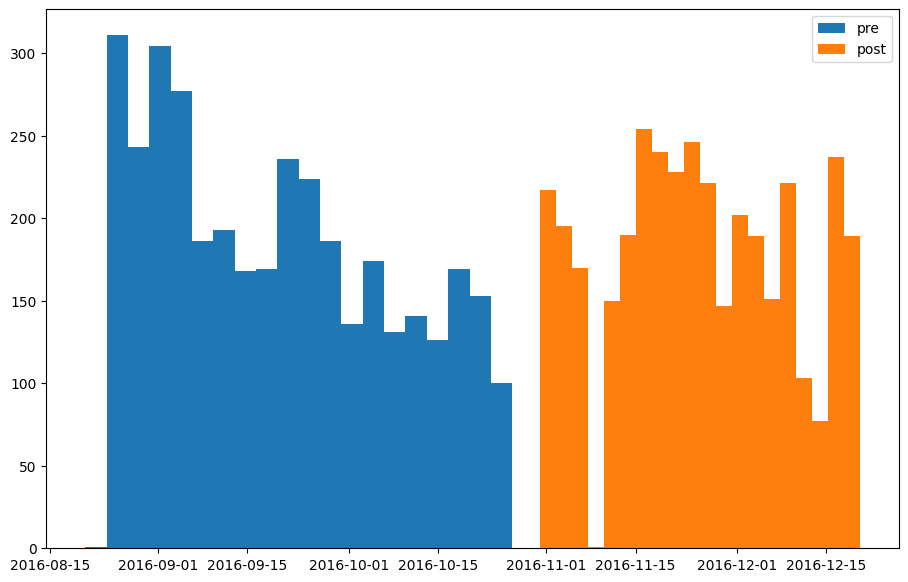

In [15]:
if num_classes==2:
    print("first event in pre is on ",df_pre['trace_start_time'].min()," last event in pre is on ",df_pre['trace_start_time'].max())
    print("first event in post is on ",df_post['trace_start_time'].min()," last event in post is on ",df_post['trace_start_time'].max())

    plt.figure(figsize=(11,7))
    plt.hist(df_pre['trace_start_time'], label='pre', bins=20)
    plt.hist(df_post['trace_start_time'], label='post', bins=20)
    plt.legend(loc='upper right')
    plt.show()
    
    
else: 
    plt.figure(figsize=(11,7))
    c=1
    for f in frames_pre:    
        print("first event in pre",c," is on ",f['trace_start_time'].min()," last event in pre",c," is on ",f['trace_start_time'].max())
        plt.hist(f['trace_start_time'], label='pre'+str(c), bins=20)
        print("label: ",f['label'][0])
        c=c+1
    if num_classes==9:
        c=1
        for f in frames_visso:
            print("first event in visso",c," is on ",f['trace_start_time'].min()," last event in visso",c," is on ",f['trace_start_time'].max())
            plt.hist(f['trace_start_time'], label='visso'+str(c), bins=20)
            print("label: ",f['label'][0])
            c=c+1
    c=1
    for f in frames_post:
        print("first event in post",c," is on ",f['trace_start_time'].min()," last event in post",c," is on ",f['trace_start_time'].max())
        plt.hist(f['trace_start_time'], label='post'+str(c), bins=20)
        print("label: ",f['label'][0])
        c=c+1

    plt.legend(loc='upper right')
    plt.show()

In [16]:
if few_shot:
    df, X_train, y_train, index_train, X_val, y_val, index_val, X_test, y_test, index_test=u.train_val_test_split(df, train_percentage=0.02, val_percentage=0.10, test_percentage=0.88, split_random=trValTest_split_rnd)
else:
    df, X_train, y_train, index_train, X_val, y_val, index_val, X_test, y_test, index_test=u.train_val_test_split(df, train_percentage=0.70, val_percentage=0.10, test_percentage=0.20, split_random=trValTest_split_rnd)


Events in train dataset:  5076
Events in validation dataset:  724
Events in test dataset:  1450
X_train.shape:  (5076, 2500, 3)
y_train.shape:  (5076, 2)
index_train.shape:  (5076, 1)
X_val.shape:  (724, 2500, 3)
y_val.shape:  (724, 2)
index_val.shape:  (724, 1)
X_test.shape:  (1450, 2500, 3)
y_test.shape:  (1450, 2)
index_test.shape:  (1450, 1)


In [17]:
batch_size = 32
if embedding_inp:
    normalization_dataloader=False
    X_train = u.normalize_for_emb(X_train)
    X_val = u.normalize_for_emb(X_val)
    X_test = u.normalize_for_emb(X_test)
else:
    normalization_dataloader=True
    

tr_dl = u.create_dataloader(X=X_train, y=y_train, index=index_train,target_dataset="train_dataset", batch_size=batch_size, normalization=normalization_dataloader)
val_dl = u.create_dataloader(X=X_val, y=y_val, index=index_val,target_dataset="val_dataset", batch_size=batch_size, normalization=normalization_dataloader)
test_dl = u.create_dataloader(X=X_test, y=y_test, index=index_test,target_dataset="test_dataset", batch_size=batch_size, normalization=normalization_dataloader)


The normalization is event-based, working on the 3 channels
The normalization is event-based, working on the 3 channels
The normalization is event-based, working on the 3 channels


In [18]:
if embedding_inp:
    netE =  EncodecModel.from_pretrained("facebook/encodec_24khz")
    netE.load_state_dict(torch.load("../models/STEAD_ch0.pth", map_location='cuda:0'))
    netE.to(device)
    netE.eval()
    netN =  EncodecModel.from_pretrained("facebook/encodec_24khz")
    netN.load_state_dict(torch.load("../models/STEAD_ch1.pth", map_location='cuda:0'))
    netN.to(device)
    netN.eval()
    netZ =  EncodecModel.from_pretrained("facebook/encodec_24khz")
    netZ.load_state_dict(torch.load("../models/STEAD_ch2.pth", map_location='cuda:0'))
    netZ.to(device)
    netZ.eval()

    print('Train:')
    def hook(module, input, output):
        outputs["conv"] = output
    enc_X=[]
    enc_y=[]
    enc_index=[]
    outputs = {}
    # hook_handle = net.decoder.layers[0].register_forward_hook(hook)
    hook_handleE = netE.encoder.layers[15].register_forward_hook(hook)
    hook_handleN = netN.encoder.layers[15].register_forward_hook(hook)
    hook_handleZ = netZ.encoder.layers[15].register_forward_hook(hook)
    with torch.no_grad():
        for idx, batch in tqdm(enumerate(tr_dl), total=len(tr_dl)):
            # print("batch[0].shape", batch[0].shape)
            E_btc=batch[0][:,:,0].unsqueeze(1).float().to(device)
            N_btc=batch[0][:,:,1].unsqueeze(1).float().to(device)
            Z_btc=batch[0][:,:,2].unsqueeze(1).float().to(device)
            # print("E_btc.shape", E_btc.shape)
            output = netE(E_btc)
            out_E=outputs["conv"]
            output = netN(N_btc)
            out_N=outputs["conv"]
            output = netZ(Z_btc)
            out_Z=outputs["conv"]
            out_chs= torch.cat((out_E,out_N,out_Z), axis=1)

            enc_X.append(out_chs)
            enc_y.append(batch[1])
            enc_index.append(batch[2])
        
    enc_X=torch.stack(enc_X)
    enc_X=enc_X.reshape(-1,enc_X.shape[2],enc_X.shape[3])
    enc_y=torch.stack(enc_y)
    enc_y=enc_y.reshape(-1,enc_y.shape[2])
    enc_index=torch.stack(enc_index)
    enc_index=enc_index.reshape(-1,enc_index.shape[2])
    print('enc_X.shape',enc_X.shape, 'enc_y.shape', enc_y.shape, 'enc_index.shape',enc_index.shape)
    dataset = TensorDataset(enc_X, enc_y, enc_index)
    tr_dl= torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True)

    print('Val')
    def hook(module, input, output):
        outputs["conv"] = output
    enc_X=[]
    enc_y=[]
    enc_index=[]
    outputs = {}
    # hook_handle = net.decoder.layers[0].register_forward_hook(hook)
    hook_handleE = netE.encoder.layers[15].register_forward_hook(hook)
    hook_handleN = netN.encoder.layers[15].register_forward_hook(hook)
    hook_handleZ = netZ.encoder.layers[15].register_forward_hook(hook)
    with torch.no_grad():
        for idx, batch in tqdm(enumerate(val_dl), total=len(val_dl)):
            E_btc=batch[0][:,:,0].unsqueeze(1).float().to(device)
            N_btc=batch[0][:,:,1].unsqueeze(1).float().to(device)
            Z_btc=batch[0][:,:,2].unsqueeze(1).float().to(device)
            # print(E_btc.shape)
            output = netE(E_btc)
            out_E=outputs["conv"]
            output = netN(N_btc)
            out_N=outputs["conv"]
            output = netZ(Z_btc)
            out_Z=outputs["conv"]
            out_chs= torch.cat((out_E,out_N,out_Z), axis=1)

            enc_X.append(out_chs)
            enc_y.append(batch[1])
            enc_index.append(batch[2])

    enc_X=torch.stack(enc_X)
    enc_X=enc_X.reshape(-1,enc_X.shape[2],enc_X.shape[3])
    enc_y=torch.stack(enc_y)
    enc_y=enc_y.reshape(-1,enc_y.shape[2])
    enc_index=torch.stack(enc_index)
    enc_index=enc_index.reshape(-1,enc_index.shape[2])
    print(enc_X.shape, enc_y.shape, enc_index.shape)
    dataset = TensorDataset(enc_X, enc_y, enc_index)
    val_dl= torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True)

    print('test')
    def hook(module, input, output):
        outputs["conv"] = output
    enc_X=[]
    enc_y=[]
    enc_index=[]
    outputs = {}
    hook_handleE = netE.encoder.layers[15].register_forward_hook(hook)
    hook_handleN = netN.encoder.layers[15].register_forward_hook(hook)
    hook_handleZ = netZ.encoder.layers[15].register_forward_hook(hook)
    with torch.no_grad():
        for idx, batch in tqdm(enumerate(test_dl), total=len(test_dl)):
            E_btc=batch[0][:,:,0].unsqueeze(1).float().to(device)
            N_btc=batch[0][:,:,1].unsqueeze(1).float().to(device)
            Z_btc=batch[0][:,:,2].unsqueeze(1).float().to(device)
            output = netE(E_btc)
            out_E=outputs["conv"]
            output = netN(N_btc)
            out_N=outputs["conv"]
            output = netZ(Z_btc)
            out_Z=outputs["conv"]
            out_chs= torch.cat((out_E,out_N,out_Z), axis=1)

            enc_X.append(out_chs)
            enc_y.append(batch[1])
            enc_index.append(batch[2])

    enc_X=torch.stack(enc_X)
    enc_X=enc_X.reshape(-1,enc_X.shape[2],enc_X.shape[3])
    enc_y=torch.stack(enc_y)
    enc_y=enc_y.reshape(-1,enc_y.shape[2])
    enc_index=torch.stack(enc_index)
    enc_index=enc_index.reshape(-1,enc_index.shape[2])
    print('enc_X.shape',enc_X.shape, 'enc_y.shape', enc_y.shape, 'enc_index.shape',enc_index.shape)
    dataset = TensorDataset(enc_X, enc_y, enc_index)
    test_dl= torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True)

    pytorch_total_params = sum(p.numel() for p in netE.parameters())
    pytorch_total_trainable_params = sum(p.numel() for p in netE.parameters() if p.requires_grad)
    print("Frozen Encoder: pytorch_total_params: "+str(pytorch_total_params)+", pytorch_total_trainable_params: "+str(pytorch_total_trainable_params))

c:\Users\Laura\Anaconda3\envs\spectrogram_zeus\lib\site-packages\torch\nn\utils\weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


Train:


  0%|          | 0/158 [00:00<?, ?it/s]

enc_X.shape torch.Size([5056, 384, 8]) enc_y.shape torch.Size([5056, 2]) enc_index.shape torch.Size([5056, 1])
Val


  0%|          | 0/22 [00:00<?, ?it/s]

torch.Size([704, 384, 8]) torch.Size([704, 2]) torch.Size([704, 1])
test


  0%|          | 0/45 [00:00<?, ?it/s]

enc_X.shape torch.Size([1440, 384, 8]) enc_y.shape torch.Size([1440, 2]) enc_index.shape torch.Size([1440, 1])
Frozen Encoder: pytorch_total_params: 14851810, pytorch_total_trainable_params: 14851810


In [ ]:
loss_function = nn.CrossEntropyLoss()
min_loss = np.Inf
loss_history_tr = []
loss_history_val = []
loss_history_te = []  
acc_history_tr = []
acc_history_val = []
acc_history_te = []
num_epochs = 50 # 100
learning_rate = 0.001#0.00001
init_lr = learning_rate
lr_decay = 0.99

inp_size=X_train.shape[1]
out_size=y_train.shape[1]
print('inp_size',inp_size, 'out_size', out_size)
s_max=False #if True it add a softmax layer before the output
if embedding_inp:
    model=u.CNN_small(num_feature=inp_size, num_class=out_size).to(device)
else:
    model=u.CNN(num_feature=inp_size, num_class=out_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)
best_model=type(model)(num_feature=inp_size, num_class=out_size).to(device)

inp_size 2500 out_size 2


In [ ]:
pytorch_total_params = sum(p.numel() for p in model.parameters())
pytorch_total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("pytorch_total_params: "+str(pytorch_total_params)+", pytorch_total_trainable_params: "+str(pytorch_total_trainable_params))

pytorch_total_params: 74434, pytorch_total_trainable_params: 74434


In [ ]:
for epoch in range(num_epochs):
    model.train()
    sum_loss_tr = 0
    sum_acc_tr = 0
    for idx, batch in tqdm(enumerate(tr_dl), total=len(tr_dl)):
        model.zero_grad() 
        inp = batch[0].to(device)
        label = batch[1].to(device)
        output = model(inp.float(), batch_size=batch_size, steps_in=inp_size, softmax=s_max)[0]
        current_loss = F.cross_entropy(output, label)
        current_loss.backward()
        optimizer.step()
        sum_loss_tr += current_loss.item()*batch_size
        confusion_matrix = torch.zeros(out_size, out_size)
        _, preds = torch.max(output, 1)
        _, classes = torch.max(label, 1)
        for t, p in zip(classes.view(-1), preds.view(-1)):
           confusion_matrix[t.long(), p.long()] += 1
        curr_avg_accuracy=(torch.mean(confusion_matrix.diag()/confusion_matrix.sum(1)).item())*100
        sum_acc_tr+=curr_avg_accuracy

    curr_tr_loss = sum_loss_tr/len(tr_dl)
    loss_history_tr.append(curr_tr_loss)
    curr_tr_acc = sum_acc_tr/len(tr_dl)
    acc_history_tr.append(curr_tr_acc)
    

    model.eval()
    with torch.no_grad():
        sum_loss_val = 0
        sum_acc_val = 0

        for idx, batch in tqdm(enumerate(val_dl), total=len(val_dl)):
            inp = batch[0].to(device)
            label = batch[1].to(device)
            output = model(inp.float(), batch_size=batch_size, steps_in=inp_size, softmax=s_max)[0]

            sum_loss_val += F.cross_entropy(output, label).item()*batch_size
            confusion_matrix = torch.zeros(out_size, out_size)
            _, preds = torch.max(output, 1)
            _, classes = torch.max(label, 1)
            for t, p in zip(classes.view(-1), preds.view(-1)):
              confusion_matrix[t.long(), p.long()] += 1
            curr_avg_accuracy=(torch.mean(confusion_matrix.diag()/confusion_matrix.sum(1)).item())*100
            sum_acc_val+=curr_avg_accuracy

        curr_val_loss = sum_loss_val/len(val_dl)
        loss_history_val.append(curr_val_loss)
        curr_val_acc = sum_acc_val/len(val_dl)
        acc_history_val.append(curr_val_acc)


        if curr_val_loss < min_loss:
            min_loss = curr_val_loss
            del best_model
            best_model = type(model)(num_feature=inp_size, num_class=out_size)
            best_model.load_state_dict(model.state_dict())
            print("Best Epoch:", epoch+1)
    print("Epoch", epoch+1, "\tTrain Loss:", curr_tr_loss, "\tValid Loss:", curr_val_loss)#, "\tTest Loss:", curr_te_loss)
    print("Train Accuracy:", curr_tr_acc, "\tValid Accuracy:", curr_val_acc)#, "\tTest Accuracy:", curr_te_acc)
    
best_model.to(dev)

inputte=[]
labeltte=[]
outputte=[]
indexte=[]
confusion_matrix = torch.zeros(out_size, out_size)

best_model.eval()
with torch.no_grad():
    sum_loss_te = 0 
    for idx, batch in tqdm(enumerate(test_dl), total=len(test_dl)):
        inp = batch[0].to(dev)
        # inp=inp[:,0:inp_size,:]
        inputte.append(inp)
        label = batch[1].to(dev)
        labeltte.append(label)
        indexte.append(batch[2].to(dev))
        output = best_model(inp.float(), batch_size=batch_size, steps_in=inp_size, softmax=s_max)[0]
        _, preds = torch.max(output, 1)
        _, classes = torch.max(label, 1)
        for t, p in zip(classes.view(-1), preds.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1               
        outputte.append(output)
        sum_loss_te += loss_function(output, label).item()*batch_size
    curr_te_loss = sum_loss_te/len(test_dl)
    print("curr_te_loss: ",curr_te_loss)
print("confusion_matrix",confusion_matrix)
print("per-class accuracy: ",[float("{:.2f}".format((t.item())*100)) for t in confusion_matrix.diag()/confusion_matrix.sum(1)]) # actually this is recall
avg_accuracy=(torch.mean(confusion_matrix.diag()/confusion_matrix.sum(1)).item())*100
print("Average accuracy: ","{:.2f}".format(avg_accuracy), "%")
confusion_matrix = (confusion_matrix/confusion_matrix.sum(axis=1))*100
if num_classes==2:
  confusion_matrix_df = pd.DataFrame(confusion_matrix).rename(columns={0:'pre',1:'post'}, index={0:'pre',1:'post'})
else:
  cols={}
  for i in range(0,int(num_classes/2)):
    cols[i]='PRE'+str(i+1)
  for i in range(int(num_classes/2),num_classes):
    cols[i]='POST'+str(i-4)
    if num_classes == 9:
      cols[4] = 'Visso'
      
  confusion_matrix_df = pd.DataFrame(confusion_matrix).rename(columns=cols, index=cols)

plt.figure(figsize=(10,10))
ax = sns.heatmap(confusion_matrix_df, annot=True, fmt=".0f", vmin=0, vmax=100)
ax.collections[0].colorbar.set_label('Performance [%]', fontsize=16, rotation=-90, labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel('Actual values', fontsize=16, color='grey')
plt.ylabel('Predicted values', fontsize=16, color='grey')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()